In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from torch.utils.data import Dataset


class MelSpectrogramDataset(Dataset):
    """Wrap `[1, T]` vibration windows → log-mel `[1, H, W]`."""

    def __init__(
        self,
        base_dataset: Dataset,
        sample_rate: int = 7400,
        image_size: tuple[int, int] = (48, 384),
        n_fft: int = 1024,
        hop_length: int = 256,
        n_mels: int = 64,
        zscore: bool = True,
    ):
        self.base = base_dataset
        self.sample_rate = int(sample_rate)
        self.h, self.w = image_size
        self.zscore = zscore

        self._mel = torch.nn.Sequential(
            torchaudio.transforms.MelSpectrogram(
                sample_rate=self.sample_rate,
                n_fft=n_fft,
                hop_length=hop_length,
                n_mels=n_mels,
                center=True,
                power=2.0,
            ),
            torchaudio.transforms.AmplitudeToDB(stype="power"),
        )

    def __len__(self) -> int:
        return len(self.base)

    def _to_image(self, x_1d: torch.Tensor) -> torch.Tensor:
        wave = x_1d.squeeze(0).float()
        feat = self._mel(wave)                 # [n_mels, T_frames]
        feat = feat.unsqueeze(0).unsqueeze(0)  # [1, 1, n_mels, T_frames]
        feat = F.interpolate(feat, size=(self.h, self.w), mode="bilinear", align_corners=False)
        out = feat.squeeze(0)                  # [1, H, W]
        if self.zscore:
            mu = out.mean()
            sd = out.std().clamp_min(1e-8)
            out = (out - mu) / sd
        return out

    def __getitem__(self, idx: int):
        x, y = self.base[idx]
        return self._to_image(x), y


class CNN2D_v1(nn.Module):
    def __init__(self, num_classes: int = 3, in_channels: int = 1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.features(x)
        h = h.flatten(1)
        return self.classifier(h)


dummy_h, dummy_w = 48, 384
_m = CNN2D_v1(num_classes=3)
_z = torch.randn(2, 1, dummy_h, dummy_w)
print("CNN2D dummy in:", _z.shape, "→ logits", _m(_z).shape)

CNN2D dummy in: torch.Size([2, 1, 48, 384]) → logits torch.Size([2, 3])


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import time


def test_accuracy(model, loss_fn, val_loader, device):
    correct = 0
    total = 0
    total_loss = 0.0

    model.eval()
    with torch.no_grad():
        for x, labels in val_loader:
            x = x.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(x)

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            loss = loss_fn(outputs, labels)
            total_loss += loss.item() * x.size(0)

    if total == 0:
        raise RuntimeError("val_loader produced no samples")

    accuracy = 100.0 * correct / total
    avg_loss = total_loss / total

    model.train()
    return accuracy, avg_loss


def train(model, loss_fn, optimizer, train_loader, val_loader, num_epochs, device):
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    epoch_durations = []

    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        total = 0
        correct = 0
        start_time = time.time()

        for x, labels in train_loader:
            x = x.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad()
            outputs = model(x)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x.size(0)

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_losses.append(total_loss / len(train_loader.dataset))
        train_accuracies.append(100 * correct / total)

        val_accuracy, val_loss = test_accuracy(model, loss_fn, val_loader, device)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(
            "Epoch [%d/%d], Train Loss: %.4f, Train Acc: %.4f, Val Loss: %.4f, Val Acc: %.4f"
            % (
                epoch + 1,
                num_epochs,
                train_losses[-1],
                train_accuracies[-1],
                val_losses[-1],
                val_accuracies[-1],
            )
        )

        epoch_duration = time.time() - start_time
        print(f"Epoch {epoch+1} finished in {epoch_duration:.2f} seconds")
        epoch_durations.append(epoch_duration)

    return train_losses, train_accuracies, val_losses, val_accuracies, epoch_durations


def plot_learning_curves(train_losses, val_losses, train_accs, val_accs):
    train_losses = [t.cpu().numpy() if isinstance(t, torch.Tensor) else t for t in train_losses]
    val_losses = [t.cpu().numpy() if isinstance(t, torch.Tensor) else t for t in val_losses]
    train_accs = [t.cpu().numpy() if isinstance(t, torch.Tensor) else t for t in train_accs]
    val_accs = [t.cpu().numpy() if isinstance(t, torch.Tensor) else t for t in val_accs]

    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Val Loss")
    plt.title("Loss Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, label="Train Acc")
    plt.plot(epochs, val_accs, label="Val Acc")
    plt.title("Accuracy Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [57]:
from pathlib import Path
import sys

_cwd = Path.cwd().resolve()
for _p in [_cwd, *_cwd.parents]:
    if (_p / "repo_paths.py").is_file():
        if str(_p) not in sys.path:
            sys.path.insert(0, str(_p))
        break
else:
    raise FileNotFoundError("Could not find repo_paths.py; open the project folder in Jupyter.")

from repo_paths import ensure_utils_importable

REPO_ROOT = ensure_utils_importable()

import torch
from torch.utils.data import DataLoader

from utils.vibration_data import make_train_val_datasets

INDEX_CSV = REPO_ROOT / "dataset" / "index.csv"
sample_rate = 7400

# Band-pass on raw waveform before z-score and mel (see `utils.vibration_data`).
# Must satisfy 0 < low < high < Nyquist (sample_rate / 2).
_BP_LOW_HZ = 300.0
_BP_HIGH_HZ = 1000.0
_BP_ORDER = 4
_BANDPASS_HZ = (_BP_LOW_HZ, _BP_HIGH_HZ)  # set to None to disable

if not INDEX_CSV.is_file():
    raise FileNotFoundError(
        f"Missing {INDEX_CSV}. Export the dataset (e.g. from utils/clip_separation.ipynb) first."
    )

train_ds_wave, val_ds_wave = make_train_val_datasets(
    str(INDEX_CSV),
    train_ratio=0.7,
    seed=67,
    sample_rate=sample_rate,
    window_seconds=6.0,
    normalize="zscore",
    bandpass_hz=_BANDPASS_HZ,
    bandpass_order=_BP_ORDER,
)

FEATURE_HW = (128, 128)

train_ds = MelSpectrogramDataset(
    train_ds_wave,
    sample_rate=sample_rate,
    image_size=FEATURE_HW,
    n_fft=1024,
    hop_length=256,
    n_mels=128,
    zscore=True,
)
val_ds = MelSpectrogramDataset(
    val_ds_wave,
    sample_rate=sample_rate,
    image_size=FEATURE_HW,
    n_fft=1024,
    hop_length=256,
    n_mels=128,
    zscore=True,
)

batch_size = 26
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=pin_memory)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, pin_memory=pin_memory)

print("Train batches:", len(train_loader), "| Val batches:", len(val_loader))
print("pin_memory:", pin_memory)
xw, yw = train_ds[0]
print("One batch item shape:", tuple(xw.shape), "label:", int(yw))

Train batches: 1 | Val batches: 4
pin_memory: False
One batch item shape: (1, 128, 128) label: 0


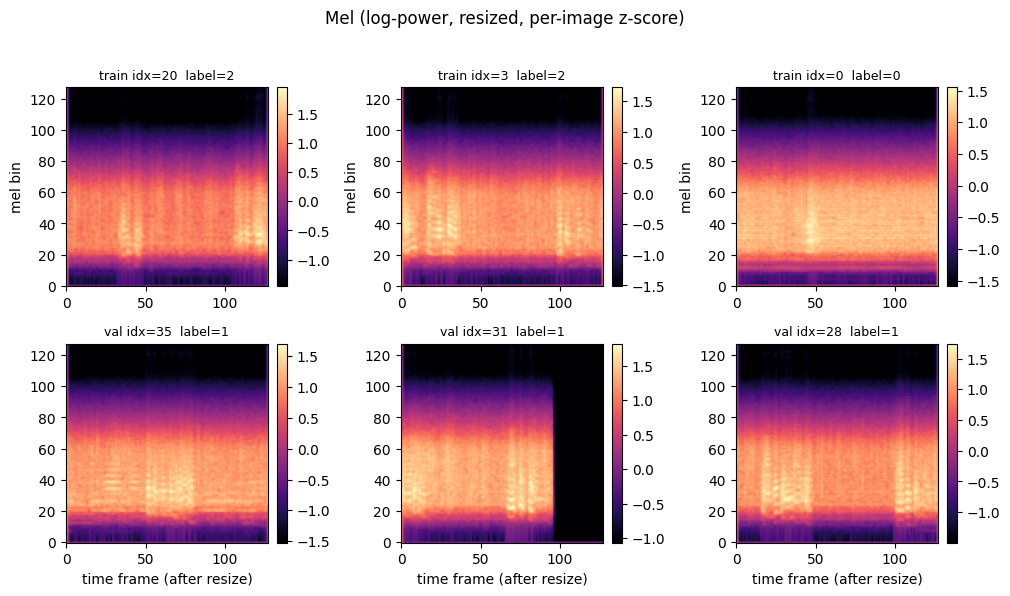

In [58]:
import random
import matplotlib.pyplot as plt

# Run after the data cell. Train windows are random crops on each access; val is fixed.
_K_TRAIN = 3
_K_VAL = 3
_PREVIEW_SEED = 42


def _to_2d(x) -> "np.ndarray":
    import numpy as np
    t = x.detach().cpu().float().squeeze()
    if t.ndim != 2:
        raise ValueError(f"Expected [H,W] after squeeze, got {tuple(t.shape)}")
    return t.numpy()


rng = random.Random(_PREVIEW_SEED)
n_tr = min(_K_TRAIN, len(train_ds))
n_va = min(_K_VAL, len(val_ds))
idx_tr = rng.sample(range(len(train_ds)), k=n_tr) if n_tr else []
idx_va = rng.sample(range(len(val_ds)), k=n_va) if n_va else []

ncols = max(len(idx_tr), len(idx_va), 1)
fig, axes = plt.subplots(2, ncols, figsize=(3.4 * ncols, 5.8), squeeze=False)
fig.suptitle("Mel (log-power, resized, per-image z-score)", fontsize=12, y=1.02)

for j in range(ncols):
    ax0 = axes[0, j]
    if j < len(idx_tr):
        x, y = train_ds[idx_tr[j]]
        im0 = ax0.imshow(_to_2d(x), aspect="auto", origin="lower", cmap="magma")
        ax0.set_title(f"train idx={idx_tr[j]}  label={int(y)}", fontsize=9)
        plt.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04)
    else:
        ax0.axis("off")
    ax0.set_ylabel("mel bin")

for j in range(ncols):
    ax1 = axes[1, j]
    if j < len(idx_va):
        x, y = val_ds[idx_va[j]]
        im1 = ax1.imshow(_to_2d(x), aspect="auto", origin="lower", cmap="magma")
        ax1.set_title(f"val idx={idx_va[j]}  label={int(y)}", fontsize=9)
        plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
    else:
        ax1.axis("off")
    ax1.set_xlabel("time frame (after resize)")

plt.tight_layout()
plt.show()

In [59]:
device = torch.device("cuda" if torch.cuda.is_available() else
                      "xpu" if torch.xpu.is_available() else
                      "cpu")

print(f"Using device: {device}")

model = CNN2D_v1(num_classes=3)
model.to(device)

num_epochs = 100
lr = 1e-3

loss_function = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

train_losses, train_accs, val_losses, val_accs, epoch_durations = train(
    model, loss_function, optimizer, train_loader, val_loader, num_epochs, device
)

Using device: xpu
Epoch [1/100], Train Loss: 1.0888, Train Acc: 38.4615, Val Loss: 1.0944, Val Acc: 35.6322
Epoch 1 finished in 1.23 seconds
Epoch [2/100], Train Loss: 1.0690, Train Acc: 38.4615, Val Loss: 1.0939, Val Acc: 36.7816
Epoch 2 finished in 0.66 seconds
Epoch [3/100], Train Loss: 1.0605, Train Acc: 38.4615, Val Loss: 1.0935, Val Acc: 36.7816
Epoch 3 finished in 0.63 seconds
Epoch [4/100], Train Loss: 1.0392, Train Acc: 38.4615, Val Loss: 1.0939, Val Acc: 36.7816
Epoch 4 finished in 0.65 seconds
Epoch [5/100], Train Loss: 1.0296, Train Acc: 42.3077, Val Loss: 1.0986, Val Acc: 27.5862
Epoch 5 finished in 0.62 seconds
Epoch [6/100], Train Loss: 0.9989, Train Acc: 53.8462, Val Loss: 1.1077, Val Acc: 27.5862
Epoch 6 finished in 0.64 seconds
Epoch [7/100], Train Loss: 1.0189, Train Acc: 57.6923, Val Loss: 1.1214, Val Acc: 27.5862
Epoch 7 finished in 0.63 seconds
Epoch [8/100], Train Loss: 0.9911, Train Acc: 50.0000, Val Loss: 1.1485, Val Acc: 27.5862
Epoch 8 finished in 0.65 second

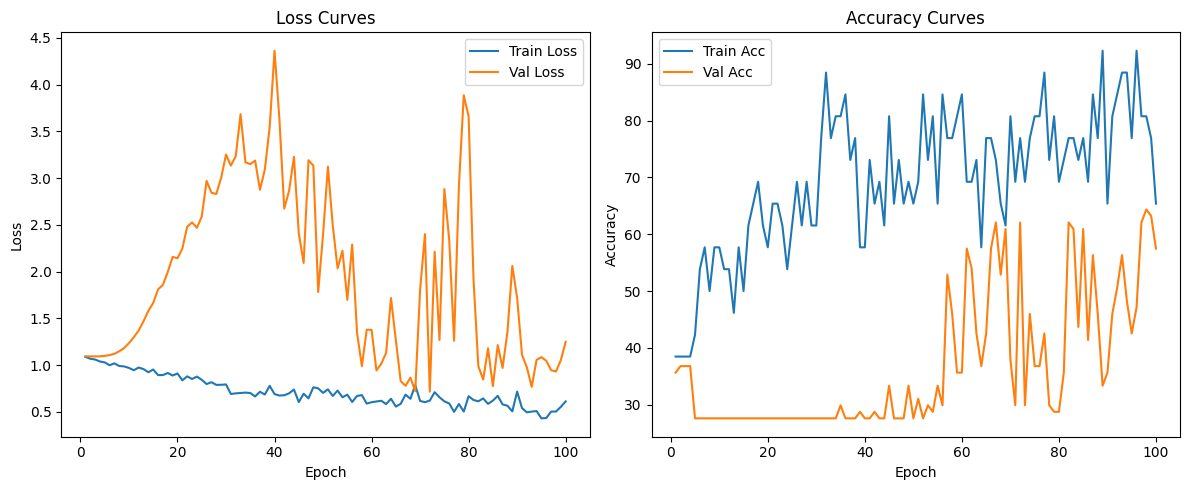

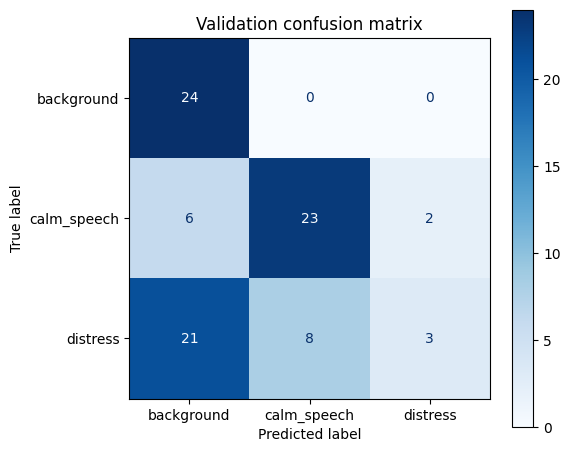

CNN2D_v1(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Linear(in_features=128, out_features=3, bias=True)
)

In [60]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

plot_learning_curves(train_losses, val_losses, train_accs, val_accs)

# Validation confusion matrix — run after training so `model`, `val_loader`, and `device` are defined.
label_names = ["background", "calm_speech", "distress"]

model.eval()
all_true, all_pred = [], []
with torch.no_grad():
    for x, labels in val_loader:
        x = x.to(device)
        logits = model(x)
        preds = logits.argmax(dim=1)
        all_true.append(labels.cpu().numpy())
        all_pred.append(preds.cpu().numpy())

y_true = np.concatenate(all_true)
y_pred = np.concatenate(all_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_pred, labels=np.arange(len(label_names))),
    display_labels=label_names,
)
disp.plot(ax=ax, values_format="d", cmap="Blues")
ax.set_title("Validation confusion matrix")
plt.tight_layout()
plt.show()

# restore training mode if you continue tuning
model.train()

x shape: (1, 48, 384)


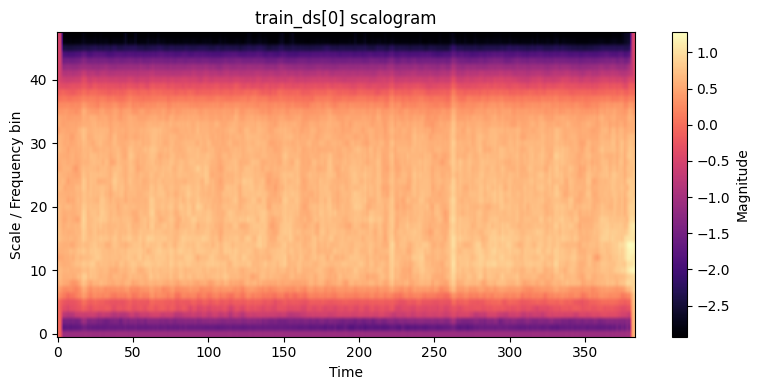

In [6]:
import matplotlib.pyplot as plt
import torch

sample = train_ds[0]

# Handle common dataset return formats:
# 1) (x, y)
# 2) {"x": x, "y": y}
if isinstance(sample, tuple) or isinstance(sample, list):
    x = sample[0]
elif isinstance(sample, dict):
    x = sample.get("x", sample.get("input"))
else:
    x = sample

# Move to CPU and numpy
if isinstance(x, torch.Tensor):
    x = x.detach().cpu()

print("x shape:", tuple(x.shape))

# Common shapes:
# [1, H, W]  -> single-channel image
# [H, W]     -> already 2D
if x.ndim == 3 and x.shape[0] == 1:
    img = x[0]
elif x.ndim == 2:
    img = x
else:
    # If shape is unexpected, pick first channel/view
    img = x.squeeze()

plt.figure(figsize=(8, 4))
plt.imshow(img, aspect='auto', origin='lower', cmap='magma')
plt.colorbar(label='Magnitude')
plt.title("train_ds[0] scalogram")
plt.xlabel("Time")
plt.ylabel("Scale / Frequency bin")
plt.tight_layout()
plt.show()